In [140]:
from cfg_tools import load_config_files

from numb_project.domain_module import get_domains_config
from numb_project.gw_model import MyGlobalWorkspace, get_global_workspace_mods
from numb_project.data_module import MnistDataModule


config = load_config_files(
    f"/home/lucas/gwnumb/config",
    use_cli=False,
    load_files=["config.yaml"])[0]

domain_configs = get_domains_config(['image', 'digit'])

gw_mod, selection_mod, operation_mod, attention_mod, loss_mod = get_global_workspace_mods(config, domain_configs)

gw = MyGlobalWorkspace.load_from_checkpoint(
    "/home/lucas/gwnumb/checkpoints/numb/pretrain_ce.ckpt",
    gw_mod=gw_mod,
    selection_mod=selection_mod,
    loss_mod=loss_mod,
    weights_only=False
    )

data_module = MnistDataModule(50)

In [150]:
z = torch.zeros([10, 10])

In [151]:
z

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [157]:
torch.ones(50, 1, device='cuda')*-1

tensor([[-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.]], device='cuda:0')

In [155]:
z

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

mu (latent VAE) shape: torch.Size([50, 12])
gw_latent (global workspace) shape: torch.Size([50, 10])
mu_reconstructed shape: torch.Size([50, 12])
reconstructed shape: torch.Size([50, 1, 28, 28])
MSE pipeline complet (image -> GW -> image): 0.041184
MSE reconstruction directe (image -> VAE seul): 0.009674
MSE round-trip latent (mu vs mu_reconstructed): 0.349684


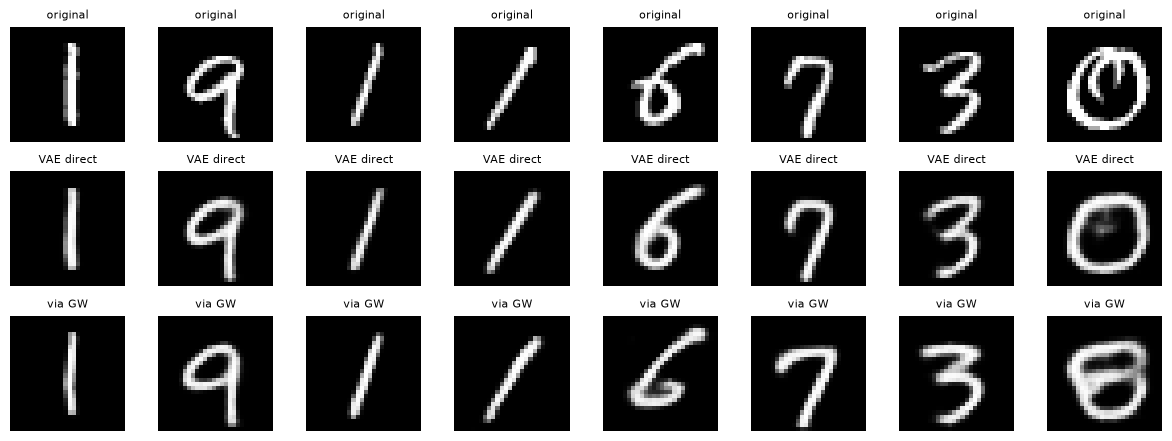

In [141]:
import matplotlib.pyplot as plt
import torch

data_loader = data_module.test_dataloader()
mnist_vae = gw.gw_mod.domain_mods.image.vae
image_encoder = gw.gw_mod.gw_encoders.image
image_decoder = gw.gw_mod.gw_decoders.image

mnist_vae.eval()
image_encoder.eval()
image_decoder.eval()

# Récupère un batch depuis le CombinedLoader
batch, batch_idx, dataloader_idx = next(iter(data_loader))

image_batch = None
for key, value in batch.items():
    if "image" in value:
        image_batch = value["image"]
        break

if image_batch is None:
    raise ValueError("Aucune clé du batch ne contient 'image'")

device = next(mnist_vae.parameters()).device
image_batch = image_batch.to(device)

with torch.no_grad():
    # 1. Image -> espace latent VAE (mu, 12D)
    mu, logvar = mnist_vae.encoder(image_batch)
    print("mu (latent VAE) shape:", mu.shape)

    # 2. Espace latent VAE -> espace global workspace
    gw_latent = image_encoder(mu)
    print("gw_latent (global workspace) shape:", gw_latent.shape)

    # 3. Espace global workspace -> espace latent VAE (retour)
    mu_reconstructed = image_decoder(gw_latent)
    print("mu_reconstructed shape:", mu_reconstructed.shape)

    # 4. Espace latent VAE -> image reconstruite
    reconstructed = mnist_vae.decoder(mu_reconstructed)
    print("reconstructed shape:", reconstructed.shape)

    # Reconstruction "directe" (sans passer par le GW) pour comparaison
    direct_reconstructed = mnist_vae.decoder(mu)

# Erreurs
mse_full_pipeline = torch.nn.functional.mse_loss(reconstructed, image_batch)
mse_direct = torch.nn.functional.mse_loss(direct_reconstructed, image_batch)
mse_latent_roundtrip = torch.nn.functional.mse_loss(mu_reconstructed, mu)

print(f"MSE pipeline complet (image -> GW -> image): {mse_full_pipeline.item():.6f}")
print(f"MSE reconstruction directe (image -> VAE seul): {mse_direct.item():.6f}")
print(f"MSE round-trip latent (mu vs mu_reconstructed): {mse_latent_roundtrip.item():.6f}")

# Visualisation : original vs reconstruction directe vs reconstruction via GW
n_show = min(8, image_batch.shape[0])
fig, axes = plt.subplots(3, n_show, figsize=(n_show * 1.5, 4.5))

for i in range(n_show):
    axes[0, i].imshow(image_batch[i, 0].cpu().numpy(), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title("original", fontsize=8)

    axes[1, i].imshow(direct_reconstructed[i, 0].cpu().numpy(), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("VAE direct", fontsize=8)

    axes[2, i].imshow(reconstructed[i, 0].cpu().numpy(), cmap="gray")
    axes[2, i].axis("off")
    axes[2, i].set_title("via GW", fontsize=8)

plt.tight_layout()
plt.show()

=== digit -> image ===
image_from_digit shape: torch.Size([50, 1, 28, 28])

=== image -> digit ===
digit_pred shape: torch.Size([50, 10])
Accuracy (image -> digit prédit): 98.00%


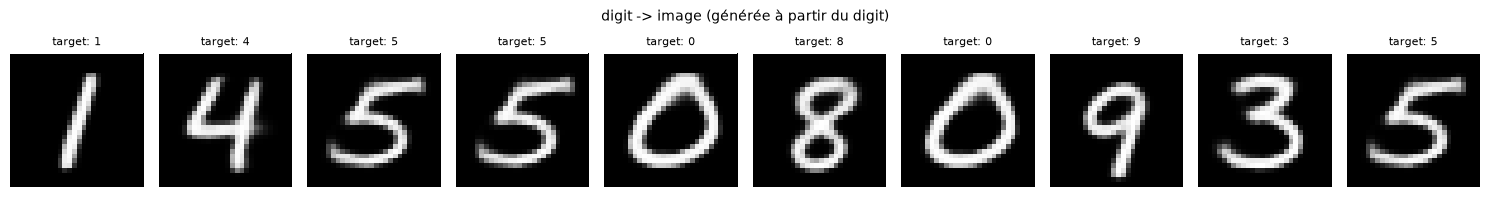

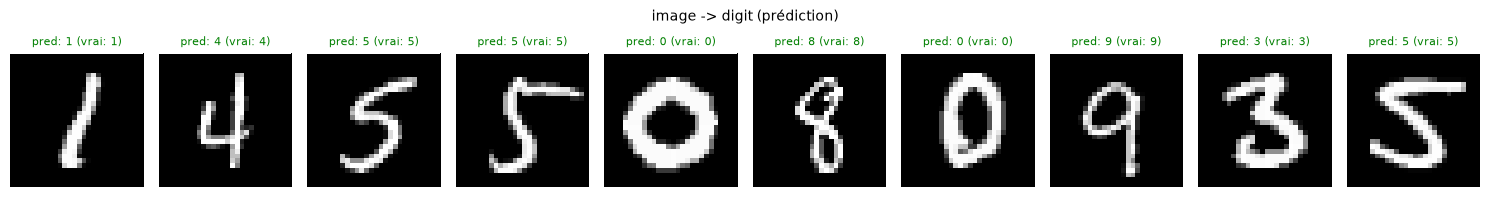

In [142]:
import matplotlib.pyplot as plt
import torch

train_loader = data_module.train_dataloader()
mnist_vae = gw.gw_mod.domain_mods.image.vae
image_encoder = gw.gw_mod.gw_encoders.image
image_decoder = gw.gw_mod.gw_decoders.image
digit_encoder = gw.gw_mod.gw_encoders.digit
digit_decoder = gw.gw_mod.gw_decoders.digit

mnist_vae.eval()
image_encoder.eval()
image_decoder.eval()
digit_encoder.eval()
digit_decoder.eval()

# Récupère un batch avec image ET digit (le domaine combiné)
batch, batch_idx, dataloader_idx = next(iter(train_loader))

image_batch, digit_batch = None, None
for key, value in batch.items():
    if "image" in value and "digit" in value:
        image_batch = value["image"]
        digit_batch = value["digit"]
        break

if image_batch is None:
    raise ValueError("Aucune clé du batch ne contient à la fois 'image' et 'digit'")

device = next(mnist_vae.parameters()).device
image_batch = image_batch.to(device)
digit_batch = digit_batch.to(device)

with torch.no_grad():
    # ---- Direction 1 : digit -> image ----
    # digit (one-hot 10D) -> espace GW
    gw_latent_from_digit = digit_encoder(digit_batch)
    # espace GW -> espace latent VAE (12D)
    mu_from_digit = image_decoder(gw_latent_from_digit)
    # espace latent VAE -> image
    image_from_digit = mnist_vae.decoder(mu_from_digit)

    # ---- Direction 2 : image -> digit ----
    # image -> espace latent VAE (12D)
    mu_from_image, _ = mnist_vae.encoder(image_batch)
    # espace latent VAE -> espace GW
    gw_latent_from_image = image_encoder(mu_from_image)
    # espace GW -> digit (one-hot 10D)
    digit_pred = digit_decoder(gw_latent_from_image)

# ---- Évaluation : digit -> image ----
true_digits = digit_batch.argmax(dim=1)
print("=== digit -> image ===")
print("image_from_digit shape:", image_from_digit.shape)

# ---- Évaluation : image -> digit ----
predicted_digits = digit_pred.argmax(dim=1)
accuracy = (predicted_digits == true_digits).float().mean()
print("\n=== image -> digit ===")
print("digit_pred shape:", digit_pred.shape)
print(f"Accuracy (image -> digit prédit): {accuracy.item():.2%}")

# ---- Visualisation : digit -> image ----
n_show = min(10, image_batch.shape[0])
fig, axes = plt.subplots(1, n_show, figsize=(n_show * 1.5, 2))
fig.suptitle("digit -> image (générée à partir du digit)", fontsize=10)

for i in range(n_show):
    axes[i].imshow(image_from_digit[i, 0].cpu().numpy(), cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"target: {true_digits[i].item()}", fontsize=8)

plt.tight_layout()
plt.show()

# ---- Visualisation : image -> digit ----
fig, axes = plt.subplots(1, n_show, figsize=(n_show * 1.5, 2))
fig.suptitle("image -> digit (prédiction)", fontsize=10)

for i in range(n_show):
    color = "green" if predicted_digits[i] == true_digits[i] else "red"
    axes[i].imshow(image_batch[i, 0].cpu().numpy(), cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(
        f"pred: {predicted_digits[i].item()} (vrai: {true_digits[i].item()})",
        fontsize=8,
        color=color,
    )

plt.tight_layout()
plt.show()


In [143]:
import torch

train_loader = data_module.train_dataloader()
mnist_vae = gw.gw_mod.domain_mods.image.vae
image_encoder = gw.gw_mod.gw_encoders.image
image_decoder = gw.gw_mod.gw_decoders.image
digit_encoder = gw.gw_mod.gw_encoders.digit
digit_decoder = gw.gw_mod.gw_decoders.digit
ope = gw.operation_module

mnist_vae.eval()
image_encoder.eval()
image_decoder.eval()
digit_encoder.eval()
digit_decoder.eval()
ope.eval()

device = next(mnist_vae.parameters()).device

# Récupère un batch avec image ET digit (le domaine combiné)
batch, batch_idx, dataloader_idx = next(iter(train_loader))

image_batch, digit_batch = None, None
for key, value in batch.items():
    if "image" in value and "digit" in value:
        image_batch = value["image"].to(device)
        digit_batch = value["digit"].to(device)
        break

if digit_batch is None:
    raise ValueError("Aucune clé du batch ne contient à la fois 'image' et 'digit'")

with torch.no_grad():
    # 1. digit one-hot -> espace GW
    gw_input = digit_encoder(digit_batch)

    # 2. Applique l'opération (-1) dans l'espace GW
    batch_size = digit_batch.shape[0]
    shift = +1
    task = torch.full(
        (batch_size, 1),
        fill_value=float(shift),
        device=device,
    )
    gw_pred = ope(gw_input, task)

    # 3. espace GW -> digit one-hot prédit
    digit_pred_logits = digit_decoder(gw_pred)
    digit_pred = digit_pred_logits.argmax(dim=1)

# Vérité terrain : digit original -1 (mod 10)
true_digits = digit_batch.argmax(dim=1)
expected_digits = (true_digits + shift) % 10

# Évaluation
accuracy = (digit_pred == expected_digits).float().mean()
print(f"Shift appliqué: {shift}")
print(f"Accuracy opération (-1): {accuracy.item():.2%}")

# Affichage détaillé de quelques exemples
n_show = min(10, batch_size)
for i in range(n_show):
    status = "✓" if digit_pred[i] == expected_digits[i] else "✗"
    print(
        f"{status} digit original: {true_digits[i].item()} "
        f"-> attendu: {expected_digits[i].item()}, "
        f"prédit: {digit_pred[i].item()}"
    )

Shift appliqué: 1
Accuracy opération (-1): 100.00%
✓ digit original: 4 -> attendu: 5, prédit: 5
✓ digit original: 3 -> attendu: 4, prédit: 4
✓ digit original: 9 -> attendu: 0, prédit: 0
✓ digit original: 7 -> attendu: 8, prédit: 8
✓ digit original: 4 -> attendu: 5, prédit: 5
✓ digit original: 4 -> attendu: 5, prédit: 5
✓ digit original: 8 -> attendu: 9, prédit: 9
✓ digit original: 1 -> attendu: 2, prédit: 2
✓ digit original: 4 -> attendu: 5, prédit: 5
✓ digit original: 4 -> attendu: 5, prédit: 5


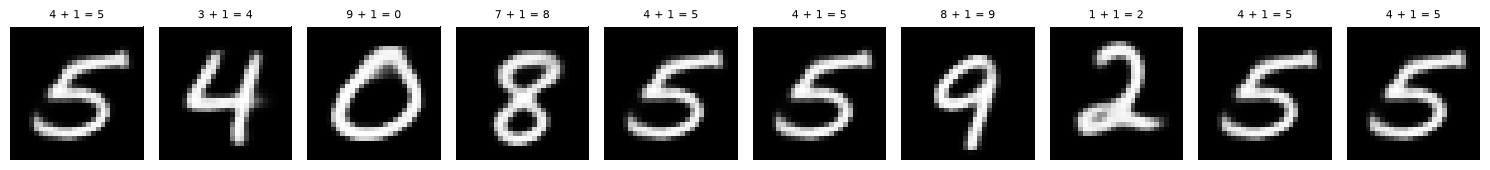

In [144]:
with torch.no_grad():
    mu_from_op = image_decoder(gw_pred)
    image_from_op = mnist_vae.decoder(mu_from_op)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, n_show, figsize=(n_show * 1.5, 2))
for i in range(n_show):
    axes[i].imshow(image_from_op[i, 0].cpu().numpy(), cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"{true_digits[i].item()} + 1 = {digit_pred[i].item()}", fontsize=8)
plt.tight_layout()
plt.show()

=== Répétition de +1 ===
Séquence: [1] (somme=1) -> accuracy: 100.00%
Séquence: [1, 1] (somme=2) -> accuracy: 100.00%
Séquence: [1, 1, 1] (somme=3) -> accuracy: 100.00%
Séquence: [1, 1, 1, 1] (somme=4) -> accuracy: 100.00%
Séquence: [1, 1, 1, 1, 1] (somme=5) -> accuracy: 100.00%

=== Répétition de -1 ===
Séquence: [-1] (somme=-1) -> accuracy: 100.00%
Séquence: [-1, -1] (somme=-2) -> accuracy: 100.00%
Séquence: [-1, -1, -1] (somme=-3) -> accuracy: 100.00%
Séquence: [-1, -1, -1, -1] (somme=-4) -> accuracy: 100.00%
Séquence: [-1, -1, -1, -1, -1] (somme=-5) -> accuracy: 100.00%

=== Combinaisons aléatoires ===
Séquence: [1, -1, 1, 1, 1] (somme=3) -> accuracy: 100.00%
Séquence: [1, 1, -1, -1] (somme=0) -> accuracy: 100.00%
Séquence: [-1, -1, 1, -1] (somme=-2) -> accuracy: 100.00%
Séquence: [-1, -1, 1, 1] (somme=0) -> accuracy: 100.00%
Séquence: [1, 1] (somme=2) -> accuracy: 100.00%

=== Accuracy moyenne par longueur de séquence (+1 répété) ===
n=1: 100.00%
n=2: 100.00%
n=3: 100.00%
n=4: 100

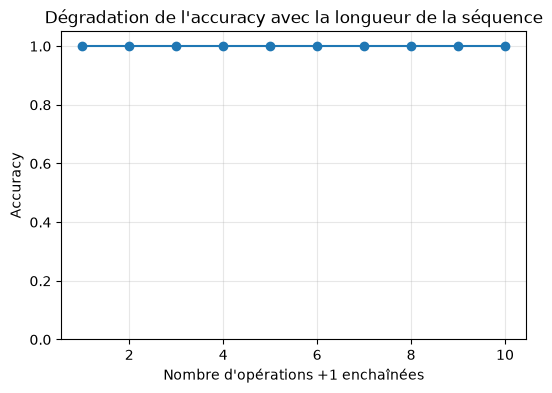

In [145]:
import torch
import matplotlib.pyplot as plt

train_loader = data_module.train_dataloader()
mnist_vae = gw.gw_mod.domain_mods.image.vae
image_decoder = gw.gw_mod.gw_decoders.image
digit_encoder = gw.gw_mod.gw_encoders.digit
digit_decoder = gw.gw_mod.gw_decoders.digit
ope = gw.operation_module

mnist_vae.eval()
image_decoder.eval()
digit_encoder.eval()
digit_decoder.eval()
ope.eval()

device = next(mnist_vae.parameters()).device


def apply_operation_sequence(digit_batch: torch.Tensor, shifts: list[int]) -> torch.Tensor:
    """
    Applique une séquence de shifts successifs dans l'espace GW.
    Retourne l'état GW final après toutes les opérations.
    """
    batch_size = digit_batch.shape[0]

    with torch.no_grad():
        gw_state = digit_encoder(digit_batch)

        for shift in shifts:
            task = torch.full(
                (batch_size, 1),
                fill_value=float(shift),
                device=device,
            )
            gw_state = ope(gw_state, task)

    return gw_state


def evaluate_sequence(digit_batch: torch.Tensor, shifts: list[int], verbose: bool = True):
    """Évalue l'accuracy après une séquence d'opérations donnée."""
    true_digits = digit_batch.argmax(dim=1)
    expected_digits = (true_digits + sum(shifts)) % 10

    gw_final = apply_operation_sequence(digit_batch, shifts)

    with torch.no_grad():
        digit_pred_logits = digit_decoder(gw_final)
        digit_pred = digit_pred_logits.argmax(dim=1)

    accuracy = (digit_pred == expected_digits).float().mean()

    if verbose:
        print(f"Séquence: {shifts} (somme={sum(shifts)}) -> accuracy: {accuracy.item():.2%}")

    return accuracy.item(), digit_pred, expected_digits, gw_final


# --- Récupère un batch ---
batch, batch_idx, dataloader_idx = next(iter(train_loader))

digit_batch = None
for key, value in batch.items():
    if "image" in value and "digit" in value:
        digit_batch = value["digit"].to(device)
        break

if digit_batch is None:
    raise ValueError("Aucune clé du batch ne contient 'digit'")

# --- Test 1 : répéter +1 plusieurs fois ---
print("=== Répétition de +1 ===")
for n in range(1, 6):
    evaluate_sequence(digit_batch, [1] * n)

print("\n=== Répétition de -1 ===")
for n in range(1, 6):
    evaluate_sequence(digit_batch, [-1] * n)

# --- Test 2 : combinaisons aléatoires ---
print("\n=== Combinaisons aléatoires ===")
import random

random.seed(0)
for _ in range(5):
    n_ops = random.randint(2, 5)
    shifts = [random.choice([-1, 1]) for _ in range(n_ops)]
    evaluate_sequence(digit_batch, shifts)

# --- Test 3 : accuracy moyenne par longueur de séquence (plus robuste) ---
print("\n=== Accuracy moyenne par longueur de séquence (+1 répété) ===")
max_len = 10
accuracies = []
for n in range(1, max_len + 1):
    acc, _, _, _ = evaluate_sequence(digit_batch, [1] * n, verbose=False)
    accuracies.append(acc)
    print(f"n={n}: {acc:.2%}")

plt.figure(figsize=(6, 4))
plt.plot(range(1, max_len + 1), accuracies, marker="o")
plt.xlabel("Nombre d'opérations +1 enchaînées")
plt.ylabel("Accuracy")
plt.title("Dégradation de l'accuracy avec la longueur de la séquence")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()